## impedance wake model 2025

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import os
from pathlib import Path
import matplotlib.patches as mpatches
from matplotlib.ticker import LogLocator
import matplotlib.ticker as ticker

In [13]:
#%% number of devices
N_tot_bellows=10000 # aggiunti 1000 bellows per le sezioni dritte
N_tot_BPM=10000 # aggiornati ad una presentazione di FCC
N_tot_RW=1 # # new machine length   
N_tot_cavities=132
N_tot_RF_tapers=33

# form factors for RW pipe 
F_xdip=0.92
F_ydip=0.99

In [65]:
project_root   = Path.cwd().parent 
element_folder = project_root / "elements"
image_folder   = project_root / "images" / "coll_square" / "taper_H15_V2.5" / "imp"
output_folder  = project_root / "output" / "coll_square" / "taper_H15_V2.5" / "imp"

# crea solo dove serve scrivere
os.makedirs(image_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)


In [66]:
# Bellows
Z_bellow_x = np.loadtxt(element_folder / "bellows" / "imp" / "Bellows_Z_NormDipImpX_sigma04mm.txt", skiprows=0)
Z_bellow_y = np.loadtxt(element_folder / "bellows" / "imp" / "Bellows_Z_NormDipImpY_sigma04mm.txt", skiprows=0)

# BPM 
Z_BPM = np.loadtxt(element_folder / "BPMs" / "imp" / "BPMs_Zx_cst_noNorm.txt",skiprows=0)
Z_BPM[:,1:3]=-Z_BPM[:,1:3]/3e-3 # normalized to transverse displacement and with opposite sign

# RF cavities
Z_cavity = np.loadtxt(element_folder / "RF_cavity" / "imp" / "RF_cavity_400MHz_Ztrans_FFT_wake.txt",skiprows=0)
Z_cavity[:,1:3]=Z_cavity[:,1:3]  # in Ohm/m

# tapers
Z_taper_in_RE = np.loadtxt(element_folder / "tapers" / "imp" / "taper_in_Z_Re_0.4_mm_transverse_dip.txt",skiprows=2)
Z_taper_in_IM = np.loadtxt(element_folder / "tapers" / "imp" / "taper_in_Z_Im_0.4_mm_transverse_dip.txt",skiprows=2)
Z_taper=np.zeros((len(Z_taper_in_RE[:,0]),3))
Z_taper[:,:-1] = Z_taper_in_RE
Z_taper[:,1] = Z_taper[:,1]*1e3 # in Ohm/m
Z_taper[:,2] = Z_taper_in_IM[:,1]*1e3 # in Ohm/m

Z_taper_out_RE = np.loadtxt(element_folder / "tapers" / "imp" / "taper_out_Z_Re_0.4_mm_transverse_dip.txt",skiprows=2)
Z_taper_out_IM = np.loadtxt(element_folder / "tapers" / "imp" / "taper_out_Z_Im_0.4_mm_transverse_dip.txt",skiprows=2)
Z_taper[:,1] = Z_taper[:,1]+Z_taper_out_RE[:,1]*1e3
Z_taper[:,2]=Z_taper[:,2]+Z_taper_out_IM[:,1]*1e3 # in Ohm/m


# Beam pipe (RW) 
Z_RW_150nm_x_RE = np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "RW_pipe_iw2d_Zx_dip_Re_150nm.txt",skiprows=0)
Z_RW_150nm_x_IM = np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "RW_pipe_iw2d_Zx_dip_Im_150nm.txt",skiprows=0)
Z_RW_150nm_x_RE[:,0]=Z_RW_150nm_x_RE[:,0]*1e-9 # from Hz to GHz 
Z_RW_150nm_x_IM[:,0]=Z_RW_150nm_x_IM[:,0]*1e-9 # from Hz to GHz
Z_RW_150nm_x_RE[:,1]=Z_RW_150nm_x_RE[:,1]*F_xdip # form factor
Z_RW_150nm_x_IM[:,1]=Z_RW_150nm_x_IM[:,1]*F_xdip # form factor

Z_RW_150nm_y_RE=np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "RW_pipe_iw2d_Zx_dip_Re_150nm.txt",skiprows=0)
Z_RW_150nm_y_IM=np.loadtxt(element_folder / "pipe" / "30mm_neg150nm" / "imp" / "RW_pipe_iw2d_Zx_dip_Im_150nm.txt",skiprows=0)
Z_RW_150nm_y_RE[:,0]=Z_RW_150nm_y_RE[:,0]*1e-9 # from Hz to GHz 
Z_RW_150nm_y_IM[:,0]=Z_RW_150nm_y_IM[:,0]*1e-9 # from Hz to GHz
Z_RW_150nm_y_RE[:,1]=Z_RW_150nm_y_RE[:,1]*F_ydip # form factor
Z_RW_150nm_y_IM[:,1]=Z_RW_150nm_y_IM[:,1]*F_ydip # form factor


#Collimators from CST
Z_coll_CST_x_RE=np.loadtxt(element_folder / "collimators" / "CST" / "square_model" / "taper_H15_V2.5" / "imp" / "Coll_CST_Zx_dip_Re_taperV_2_5_taperH_15.txt",skiprows=0)
Z_coll_CST_x_IM=np.loadtxt(element_folder / "collimators" / "CST" / "square_model" / "taper_H15_V2.5" / "imp" / "Coll_CST_Zx_dip_Im_taperV_2_5_taperH_15.txt",skiprows=0)
Z_coll_CST_x_RE[:,0]=Z_coll_CST_x_RE[:,0]*1e-9 # from Hz to GHz
Z_coll_CST_x_IM[:,0]=Z_coll_CST_x_IM[:,0]*1e-9 # from Hz to GHz
Z_coll_CST_x_RE[:,1]=Z_coll_CST_x_RE[:,1]
Z_coll_CST_x_IM[:,1]=Z_coll_CST_x_IM[:,1]

Z_coll_CST_y_RE=np.loadtxt(element_folder / "collimators" / "CST" / "square_model" / "taper_H15_V2.5" / "imp" / "Coll_CST_Zy_dip_Im_taperV_2_5_taperH_15.txt",skiprows=0)
Z_coll_CST_y_IM=np.loadtxt(element_folder / "collimators" / "CST" / "square_model" / "taper_H15_V2.5" / "imp" / "Coll_CST_Zy_dip_Re_taperV_2_5_taperH_15.txt",skiprows=0)
Z_coll_CST_y_RE[:,0]=Z_coll_CST_y_RE[:,0]*1e-9 # from Hz to GHz
Z_coll_CST_y_IM[:,0]=Z_coll_CST_y_IM[:,0]*1e-9 # from Hz to GHz
Z_coll_CST_y_RE[:,1]=Z_coll_CST_y_RE[:,1]
Z_coll_CST_y_IM[:,1]=Z_coll_CST_y_IM[:,1]

# RW collimators
Z_coll_IW2D_x_RE=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "tot" / "imp" / "Coll_iw2d_Zx_dip_Re_150nm.txt",skiprows=0)
Z_coll_IW2D_x_IM=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "tot" / "imp" / "Coll_iw2d_Zx_dip_Im_150nm.txt",skiprows=0)
Z_coll_IW2D_x_RE[:,0]=Z_coll_IW2D_x_RE[:,0]*1e-9 # from Hz to GHz
Z_coll_IW2D_x_IM[:,0]=Z_coll_IW2D_x_IM[:,0]*1e-9 # from Hz to GHz


Z_coll_IW2D_y_RE=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "tot" / "imp" / "Coll_iw2d_Zy_dip_Re_150nm.txt",skiprows=0)
Z_coll_IW2D_y_IM=np.loadtxt(element_folder / "collimators" / "RW" / "GHC" / "v23" / "tot" / "imp" / "Coll_iw2d_Zy_dip_Im_150nm.txt",skiprows=0)
Z_coll_IW2D_y_RE[:,0]=Z_coll_IW2D_y_RE[:,0]*1e-9 # from Hz to GHz
Z_coll_IW2D_y_IM[:,0]=Z_coll_IW2D_y_IM[:,0]*1e-9 # from Hz to GHz



In [67]:
#%% frequency interpolation
frequency=np.linspace(0,50,5001)

Z_belx=np.zeros((len(frequency),len(frequency)))
Z_belx[:,0]=np.interp(frequency,Z_bellow_x[:,0],Z_bellow_x[:,1])
Z_belx[:,1]=np.interp(frequency,Z_bellow_x[:,0],Z_bellow_x[:,2])
Z_belx=Z_belx*N_tot_bellows

Z_bely=np.zeros((len(frequency),len(frequency)))
Z_bely[:,0]=np.interp(frequency,Z_bellow_y[:,0],Z_bellow_y[:,1])
Z_bely[:,1]=np.interp(frequency,Z_bellow_y[:,0],Z_bellow_y[:,2])
Z_bely=Z_bely*N_tot_bellows

Z_bpm=np.zeros((len(frequency),len(frequency)))
Z_bpm[:,0]=np.interp(frequency,Z_BPM[:,0],Z_BPM[:,1])
Z_bpm[:,1]=np.interp(frequency,Z_BPM[:,0],Z_BPM[:,2])
Z_bpm=Z_bpm*N_tot_BPM

Z_rw_x=np.zeros((len(frequency),len(frequency)))
Z_rw_x[:,0]=np.interp(frequency,Z_RW_150nm_x_RE[:,0],Z_RW_150nm_x_RE[:,1])
Z_rw_x[:,1]=np.interp(frequency,Z_RW_150nm_x_IM[:,0],Z_RW_150nm_x_IM[:,1])
Z_rw_x=Z_rw_x*N_tot_RW

Z_rw_y=np.zeros((len(frequency),len(frequency)))
Z_rw_y[:,0]=np.interp(frequency,Z_RW_150nm_y_RE[:,0],Z_RW_150nm_y_RE[:,1])
Z_rw_y[:,1]=np.interp(frequency,Z_RW_150nm_y_IM[:,0],Z_RW_150nm_y_IM[:,1])
Z_rw_y=Z_rw_y*N_tot_RW

Z_coll_cst_x=np.zeros((len(frequency),len(frequency)))
Z_coll_cst_x[:,0]=np.interp(frequency,Z_coll_CST_x_RE[:,0],Z_coll_CST_x_RE[:,1])
Z_coll_cst_x[:,1]=np.interp(frequency,Z_coll_CST_x_IM[:,0],Z_coll_CST_x_IM[:,1])
Z_coll_cst_x=Z_coll_cst_x*N_tot_collimators

Z_coll_cst_y=np.zeros((len(frequency),len(frequency)))
Z_coll_cst_y[:,0]=np.interp(frequency,Z_coll_CST_y_RE[:,0],Z_coll_CST_y_RE[:,1])
Z_coll_cst_y[:,1]=np.interp(frequency,Z_coll_CST_y_IM[:,0],Z_coll_CST_y_IM[:,1])
Z_coll_cst_y=Z_coll_cst_y*N_tot_collimators

Z_cav=np.zeros((len(frequency),len(frequency)))
Z_cav[:,0]=np.interp(frequency,Z_cavity[:,0],Z_cavity[:,1])
Z_cav[:,1]=np.interp(frequency,Z_cavity[:,0],Z_cavity[:,2])
Z_cav=Z_cav*N_tot_cavities

Z_RF_tap=np.zeros((len(frequency),len(frequency)))
Z_RF_tap[:,0]=np.interp(frequency,Z_taper[:,0],Z_taper[:,1])
Z_RF_tap[:,1]=np.interp(frequency,Z_taper[:,0],Z_taper[:,2])
Z_RF_tap=Z_RF_tap*N_tot_RF_tapers

Z_coll_iw2d_x=np.zeros((len(frequency),len(frequency)))
Z_coll_iw2d_x[:,0]=np.interp(frequency,Z_coll_IW2D_x_RE[:,0],Z_coll_IW2D_x_RE[:,1])
Z_coll_iw2d_x[:,1]=np.interp(frequency,Z_coll_IW2D_x_IM[:,0],Z_coll_IW2D_x_IM[:,1])

Z_coll_iw2d_y=np.zeros((len(frequency),len(frequency)))
Z_coll_iw2d_y[:,0]=np.interp(frequency,Z_coll_IW2D_y_RE[:,0],Z_coll_IW2D_y_RE[:,1])
Z_coll_iw2d_y[:,1]=np.interp(frequency,Z_coll_IW2D_y_IM[:,0],Z_coll_IW2D_y_IM[:,1])

In [68]:
#%% total impedance

Z_totx=Z_belx+Z_bpm+Z_rw_x+Z_cav+Z_RF_tap+Z_coll_iw2d_x
Z_toty=Z_bely+Z_bpm+Z_rw_y+Z_cav+Z_RF_tap+Z_coll_iw2d_y
Z_geom_coll_x=Z_coll_cst_x-Z_coll_iw2d_x
Z_geom_coll_y=Z_coll_cst_y-Z_coll_iw2d_y

Z_totx=Z_totx+Z_geom_coll_x
Z_toty=Z_toty+Z_geom_coll_y


In [69]:
# %pip install ipympl ipywidgets

## Elements contribution:  Im[$Z_{y}$] ($\Omega$/m)


In [70]:
fntsz = 18
mpl.rcParams.update({
    'font.size': fntsz,
    'axes.titlesize': fntsz,
    'axes.labelsize': fntsz,
    'xtick.labelsize': fntsz,
    'ytick.labelsize': fntsz,
    'legend.fontsize': fntsz-2, 
})

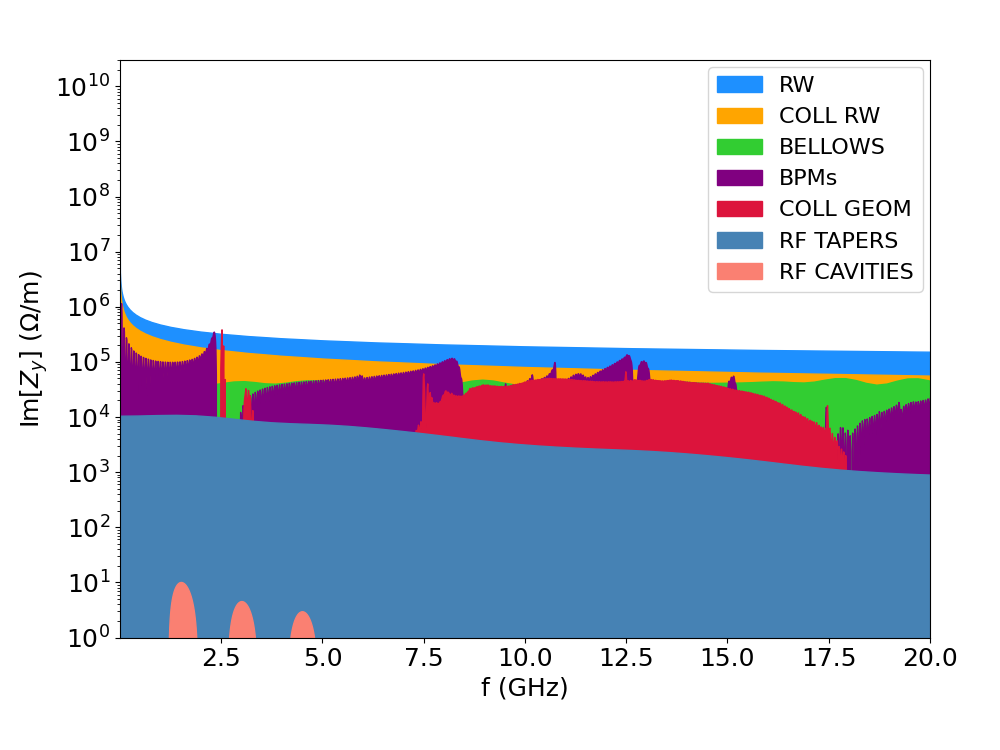

In [71]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Im[$Z_{y}$] ($\Omega$/m)')

ax.fill_between(frequency, Z_rw_y[:, 1], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency, Z_coll_iw2d_y[:, 1], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_bely[:, 1], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_bpm[:, 1], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency[start_idx:end_idx], Z_geom_coll_y[start_idx:end_idx, 1], color='crimson', alpha=1, label='Coll. geom.')
ax.fill_between(frequency, Z_RF_tap[:, 1], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_cav[:, 1], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='crimson', label='COLL GEOM'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.005, 1.007))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e0, 3e10)
ax.set_xscale('linear')
ax.set_yscale('log')
ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=16))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=80)) 

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Zy_dip_Im_log_area.jpg", dpi=300, bbox_inches='tight')


## Elements contribution:  Im[$Z_{x}$] ($\Omega$/m)

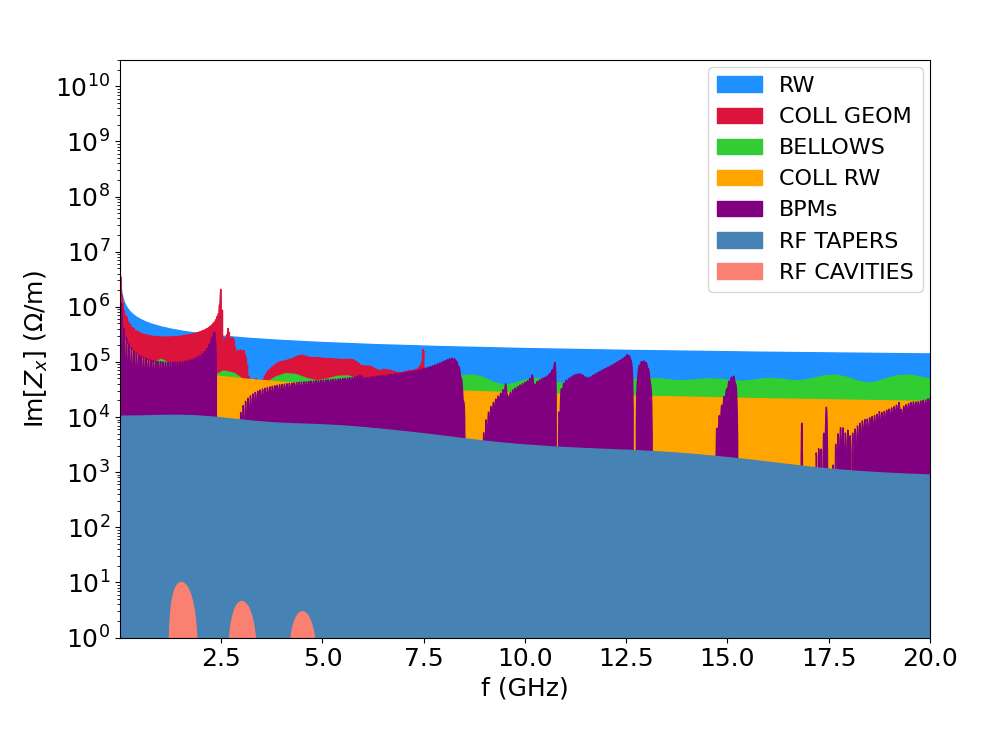

In [72]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Im[$Z_{x}$] ($\Omega$/m)')


ax.fill_between(frequency, Z_rw_x[:, 1], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency[start_idx:end_idx], Z_geom_coll_x[start_idx:end_idx, 1], color='crimson', alpha=1, label='Coll. geom.')
ax.fill_between(frequency, Z_belx[:, 1], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_coll_iw2d_x[:, 1], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_bpm[:, 1], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency, Z_RF_tap[:, 1], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_cav[:, 1], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='crimson', label='COLL GEOM'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.005, 1.007))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e0, 3e10)
ax.set_xscale('linear')
ax.set_yscale('log')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=16))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=80)) 

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Zx_dip_Im_log_area.jpg", dpi=300, bbox_inches='tight')

## Elements contribution:  Re[$Z_{y}$] ($\Omega$/m)

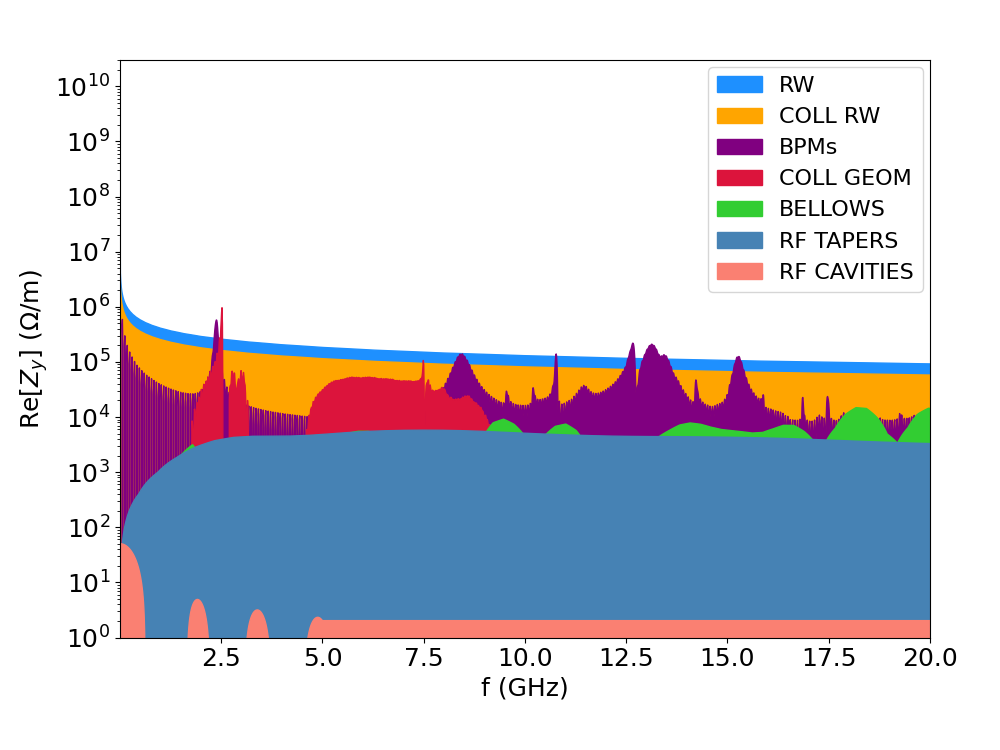

In [73]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Re[$Z_{y}$] ($\Omega$/m)')

ax.fill_between(frequency, Z_rw_y[:, 0], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency, Z_coll_iw2d_y[:, 0], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_bpm[:, 0], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency[start_idx:end_idx], Z_geom_coll_y[start_idx:end_idx, 0], color='crimson', alpha=1, label='Coll. geom.')
ax.fill_between(frequency, Z_bely[:, 0], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_RF_tap[:, 0], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_cav[:, 0], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='crimson', label='COLL GEOM'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.005, 1.007))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e0, 3e10)
ax.set_xscale('linear')
ax.set_yscale('log')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=16))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=80)) 

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Zy_dip_Re_log_area.jpg", dpi=300, bbox_inches='tight')

## Elements contribution:  Re[$Z_{x}$] ($\Omega$/m)

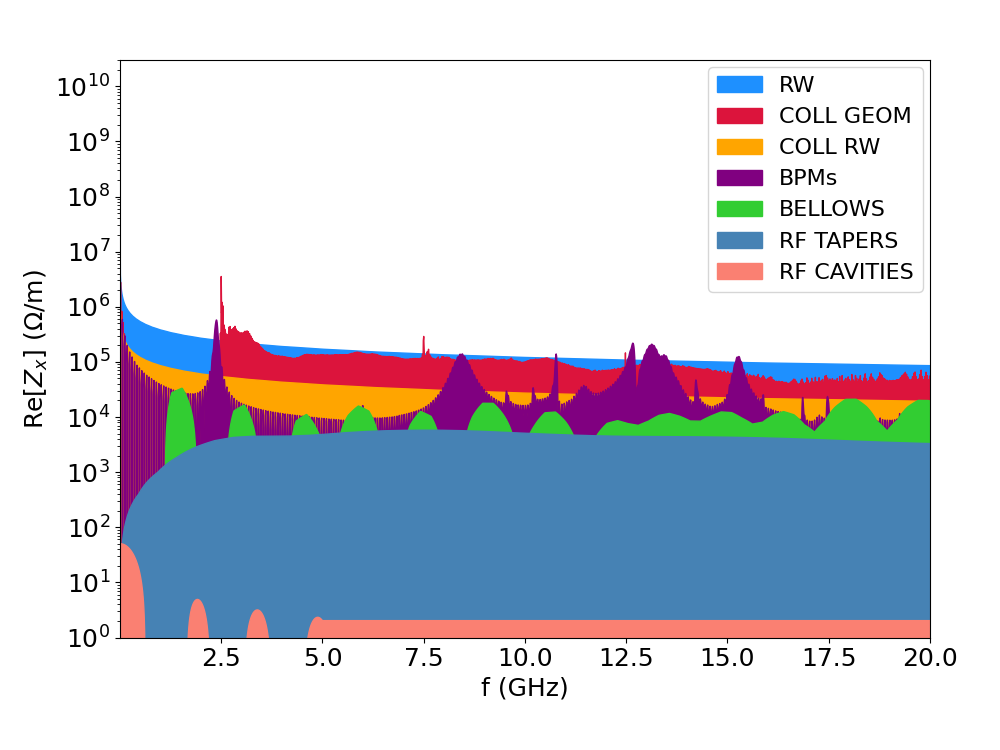

In [74]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'Re[$Z_{x}$] ($\Omega$/m)')

ax.fill_between(frequency, Z_rw_x[:, 0], color='dodgerblue', alpha=1, label='RW pipe')
ax.fill_between(frequency[start_idx:end_idx], Z_geom_coll_x[start_idx:end_idx, 0], color='crimson', alpha=1, label='Coll. geom.')
ax.fill_between(frequency, Z_coll_iw2d_x[:, 0], color='orange', alpha=1, label='Coll. RW')
ax.fill_between(frequency, Z_bpm[:, 0], color='purple', alpha=1, label='BPMs')
ax.fill_between(frequency, Z_belx[:, 0], color='limegreen', alpha=1, label='Bellows')
ax.fill_between(frequency, Z_RF_tap[:, 0], color='steelblue', alpha=1, label='RF tapers')
ax.fill_between(frequency, Z_cav[:, 0], color='salmon', alpha=1, label='RF cavities')

legend_patches = [
    mpatches.Patch(color='dodgerblue', label='RW'),
    mpatches.Patch(color='crimson', label='COLL GEOM'),
    mpatches.Patch(color='orange', label='COLL RW'),
    mpatches.Patch(color='purple', label='BPMs'),
    mpatches.Patch(color='limegreen', label='BELLOWS'),
    mpatches.Patch(color='steelblue', label='RF TAPERS'),
    mpatches.Patch(color='salmon', label='RF CAVITIES')
]

ax.legend(handles=legend_patches, loc='upper right', bbox_to_anchor=(1.005, 1.007))

ax.set_xlim(1e-3, 20)
ax.set_ylim(1e0, 3e10)
ax.set_xscale('linear')
ax.set_yscale('log')

ax.yaxis.set_major_locator(LogLocator(base=10.0, subs=(1.0,), numticks=16))
ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=np.arange(2, 10)*0.1, numticks=80)) 

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Zx_dip_Re_log_area.jpg", dpi=300, bbox_inches='tight')


## Total contribution: $Z^{tot}_{x,y}$ ($\Omega$/m)

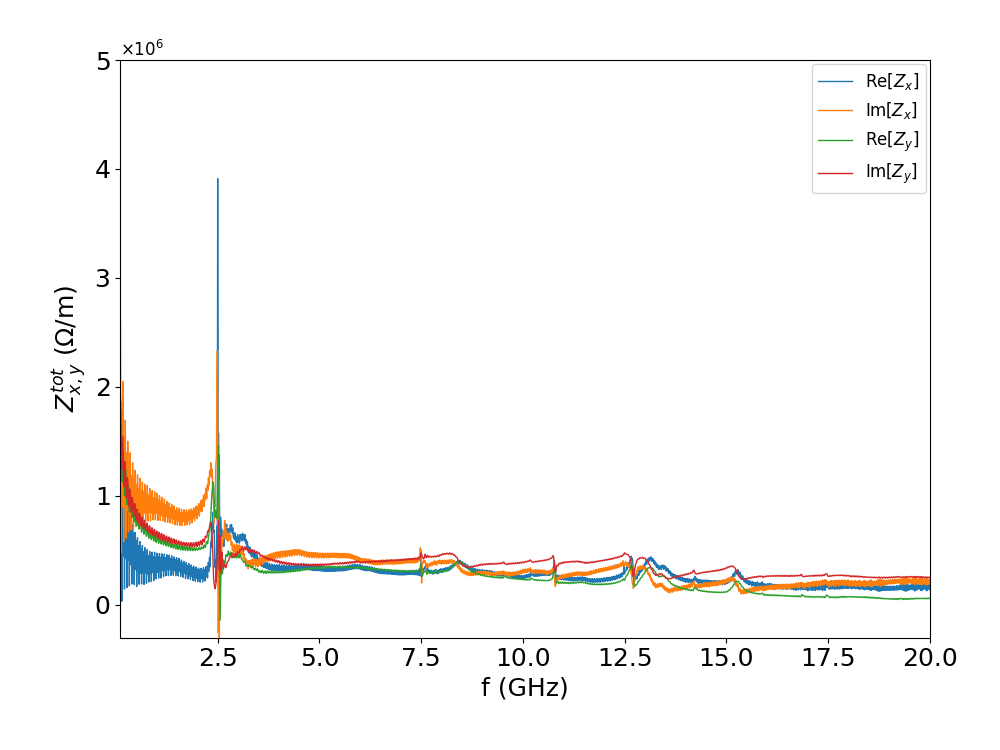

In [75]:
%matplotlib ipympl

plt.close('all')
fig, ax = plt.subplots(figsize=(10, 7.5)) 

ax.set_xlabel('f (GHz)')
ax.set_ylabel(r'$Z^{tot}_{x,y}$ ($\Omega$/m)')

ax.plot(frequency,Z_totx[:,0],linewidth=1,label=r'Re[$Z_{x}$]')
ax.plot(frequency,Z_totx[:,1],linewidth=1,label=r'Im[$Z_{x}$]')
ax.plot(frequency,Z_toty[:,0],linewidth=1,label= r'Re[$Z_{y}$]')
ax.plot(frequency,Z_toty[:,1],linewidth=1,label=r'Im[$Z_{y}$]')

ax.set_xlim(1e-1,20)
ax.set_ylim(-3e5,0.5e7)
ax.set_xscale('linear')
ax.set_yscale('linear')

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.yaxis.get_major_formatter().set_scientific(True)
ax.yaxis.get_major_formatter().set_powerlimits((-2, 2))
ax.yaxis.get_offset_text().set_fontsize(fonts_size)
ax.legend( loc='upper right', fontsize=fonts_size, bbox_to_anchor=(1.005, 1.007))

fig.subplots_adjust(left=0.12, right=0.93, bottom=0.15, top=0.92)
plt.savefig(image_folder / "Z_dip_tot_lin.jpg", dpi=300, bbox_inches='tight')

### Export $Z^{tot}_{x,y}$ ($\Omega$/m)

In [76]:
head='f (GHz)        Re[Z] (Ohm/m)     Im[Z] (Ohm/m)'
np.savetxt(output_folder / "impedance_dip_X.txt", list(zip(frequency,Z_totx[:,0],Z_totx[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')
np.savetxt(output_folder / "impedance_dip_Y.txt", list(zip(frequency,Z_toty[:,0],Z_toty[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')

head='f (GHz)        Re[Z] (Ohm/m)     Im[Z] (Ohm/m)'
np.savetxt(output_folder / "coll_rw_dip_X.txt", list(zip(frequency,Z_coll_iw2d_x[:,0],Z_coll_iw2d_x[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')
np.savetxt(output_folder / "coll_rw_dip_Y.txt", list(zip(frequency,Z_coll_iw2d_y[:,0],Z_coll_iw2d_y[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')

head='f (GHz)        Re[Z] (Ohm/m)     Im[Z] (Ohm/m)'
np.savetxt(output_folder / "coll_geom_dip_X.txt", list(zip(frequency,Z_geom_coll_x[:,0],Z_geom_coll_x[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')
np.savetxt(output_folder / "coll_geom_dip_Y.txt", list(zip(frequency,Z_geom_coll_y[:,0],Z_geom_coll_y[:,1])),
                                     fmt='%.6e',header=head,delimiter='    ')